In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
opacity_path = r"C:\DEEP LEARNING\xray_pnemonia\archive (11)\chest_xray\test\PNEUMONIA"

normal_path = r"C:\DEEP LEARNING\xray_pnemonia\archive (11)\chest_xray\test\PNEUMONIA"

In [3]:
#Image parameters

In [3]:
IMG_SIZE = (150, 150)

BATCH_SIZE = 32

In [4]:
opacity_image = glob.glob(opacity_path + r"\*.*")

print("Number of Opacity image:", len(opacity_image))

normal_image = glob.glob(normal_path + r"\*.*")

print("Number of Normal image:", len(normal_image))

Number of Opacity image: 390
Number of Normal image: 390


In [5]:
opacity_df = pd.DataFrame({"Filename": opacity_image,
                        "label" : 1})

normal_df = pd.DataFrame({"Filename" : normal_image,
                         "label" : 0})

df = pd.concat([opacity_df,
                normal_df], ignore_index = True)

In [9]:
#Display Dataset Information

In [6]:
print("\n Dataset Shape: ")
print(df.shape)
print("\n First 5 Records: ")
print(df.head())
print("\n Last 5 Records: ")
print(df.tail())
print("\n Missing Value: ")
print(df.isnull().sum())
print("\n Duplicate Records: ")
print(df.duplicated().sum())
df = df.drop_duplicates()



 Dataset Shape: 
(780, 2)

 First 5 Records: 
                                            Filename  label
0  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      1
1  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      1
2  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      1
3  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      1
4  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      1

 Last 5 Records: 
                                              Filename  label
775  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      0
776  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      0
777  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      0
778  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      0
779  C:\DEEP LEARNING\xray_pnemonia\archive (11)\ch...      0

 Missing Value: 
Filename    0
label       0
dtype: int64

 Duplicate Records: 
0


In [7]:
print("\n Class Distribution: ")
print(df["label"].value_counts())

print("\n Class Names: ")
print(
    df["label"].value_counts().rename(
        index = {0: "NORMAL", 1: "OPACITY"}
    )
)


 Class Distribution: 
label
1    390
0    390
Name: count, dtype: int64

 Class Names: 
label
OPACITY    390
NORMAL     390
Name: count, dtype: int64


In [12]:
# SHUFFLE DATA

In [8]:
df = df.sample(frac=1,random_state=42
).reset_index(drop=True)

train_df, test_df = train_test_split(df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"])

print("\nTraining Images:",len(train_df))
print("Testing Images:",len(test_df))


Training Images: 624
Testing Images: 156


In [9]:
#IMAGE DATA GENERATOR

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.20)

# TEST DATA GENERATOR

test_datagen = ImageDataGenerator(
    rescale=1./255)

#TRAINING DATA GENERATOR

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="Filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training",
    shuffle=True)

#VALIDATION DATA GENERATOR

validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="Filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation",
    shuffle=False)

# TEST DATA GENERATOR

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="Filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False)

Found 500 validated image filenames.
Found 124 validated image filenames.
Found 156 validated image filenames.


In [15]:
# DISPLAY GENERATOR INFORMATION

In [10]:
print("\nTraining Samples:",train_generator.samples)
print("Validation Samples:",validation_generator.samples)
print("Testing Samples:",test_generator.samples)


Training Samples: 500
Validation Samples: 124
Testing Samples: 156


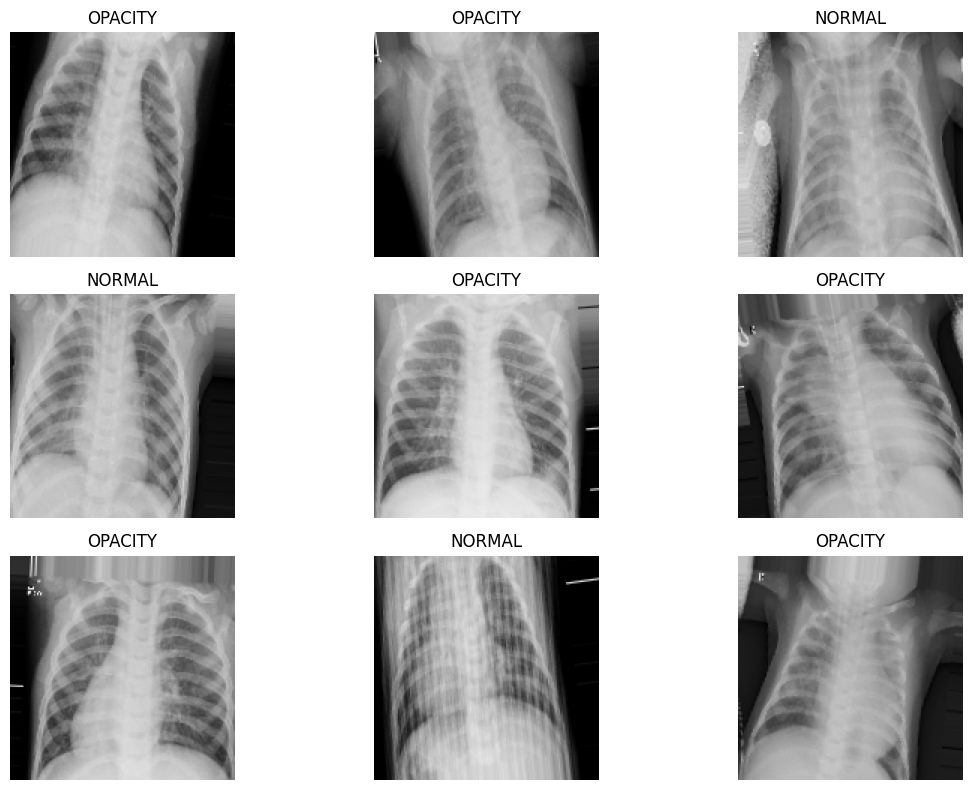

In [11]:
image, labels = next(train_generator)
plt.figure(figsize = (12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image[i])

    if labels[i] == 1:
        plt.title("OPACITY")
    else:
        plt.title("NORMAL")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
model = Sequential([

    Conv2D(32, (3,3), activation = "relu",
           input_shape = (150, 150, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation = "relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation = "relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation = "relu"),

    Dropout(0.5),

    Dense(1, activation = "sigmoid") 
])

c:\Users\aj381\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [13]:
model.summary()

model.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"]
             )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(train_generator,
                   validation_data = validation_generator,
                    epochs = 10
                   )

test_loss, test_accuracy = model.evaluate(test_generator)
print("TEST RESULTS")
print("Test Loss : ", test_loss)
print("Test Acuuracy : ", test_accuracy)

Epoch 1/10


c:\Users\aj381\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 965ms/step - accuracy: 0.5028 - loss: 0.9828 - val_accuracy: 0.5081 - val_loss: 0.6933
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 557ms/step - accuracy: 0.4885 - loss: 0.6937 - val_accuracy: 0.5161 - val_loss: 0.6932
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 531ms/step - accuracy: 0.4567 - loss: 0.6932 - val_accuracy: 0.4194 - val_loss: 0.6932
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 551ms/step - accuracy: 0.5176 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 565ms/step - accuracy: 0.4852 - loss: 0.6932 - val_accuracy: 0.4677 - val_loss: 0.6937
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 588ms/step - accuracy: 0.4884 - loss: 0.6957 - val_accuracy: 0.5081 - val_loss: 0.6933
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 599ms/step - accuracy: 0.4716 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 558ms/step - accuracy: 0.4468 - loss: 0.6933 - val_accuracy: 0.508

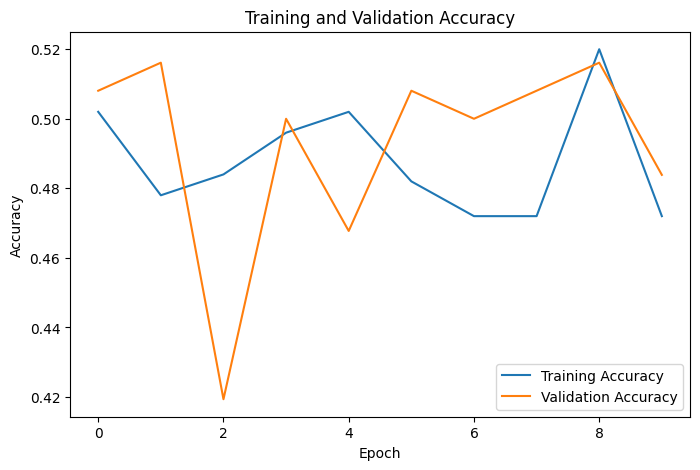

In [15]:
plt.figure(figsize = (8, 5))

#Accuracy Plot

plt.plot(history.history["accuracy"],
         label = "Training Accuracy")
plt.plot(history.history["val_accuracy"],
        label = "Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

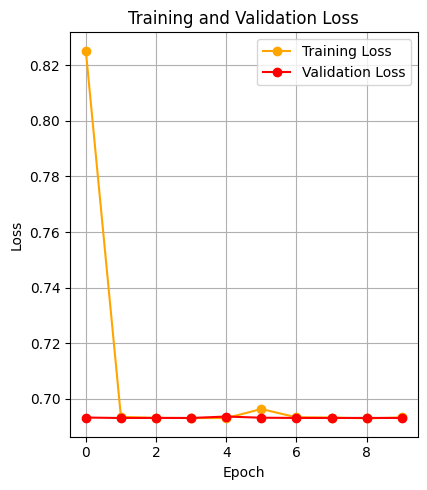

In [16]:
plt.figure(figsize = (8, 5))

#Loss Plot

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss", color='orange', marker='o')
plt.plot(history.history["val_loss"], label="Validation Loss", color='red', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step

Image Used For Prediction:
C:\DEEP LEARNING\xray_pnemonia\archive (11)\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

Prediction Probability: 0.50045663
Prediction: PNEUMONIA


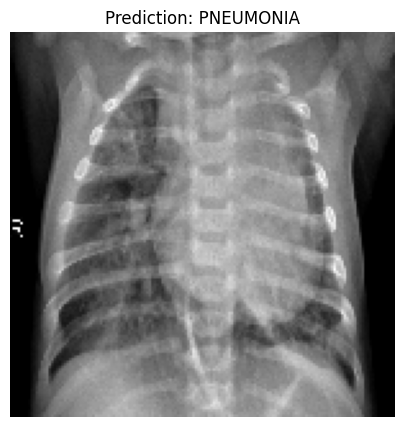

In [17]:
test_generator.reset()
predictions = model.predict(test_generator)

predicted_classes = (predictions >= 0.5).astype(int).flatten()

image_path = opacity_image[0]
print("\nImage Used For Prediction:")
print(image_path)

img = tf.keras.utils.load_img(image_path,
    target_size=IMG_SIZE)


img_array = tf.keras.utils.img_to_array(img)


img_array = np.expand_dims(img_array,axis=0)


img_array = img_array / 255.0


prediction = model.predict(img_array)
probability = prediction[0][0]
print("\nPrediction Probability:",probability)


plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
if probability >= 0.5:
    print("Prediction: PNEUMONIA")
    plt.title("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")
    plt.title("Prediction: NORMAL")
plt.show()